In [2]:
#lab4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

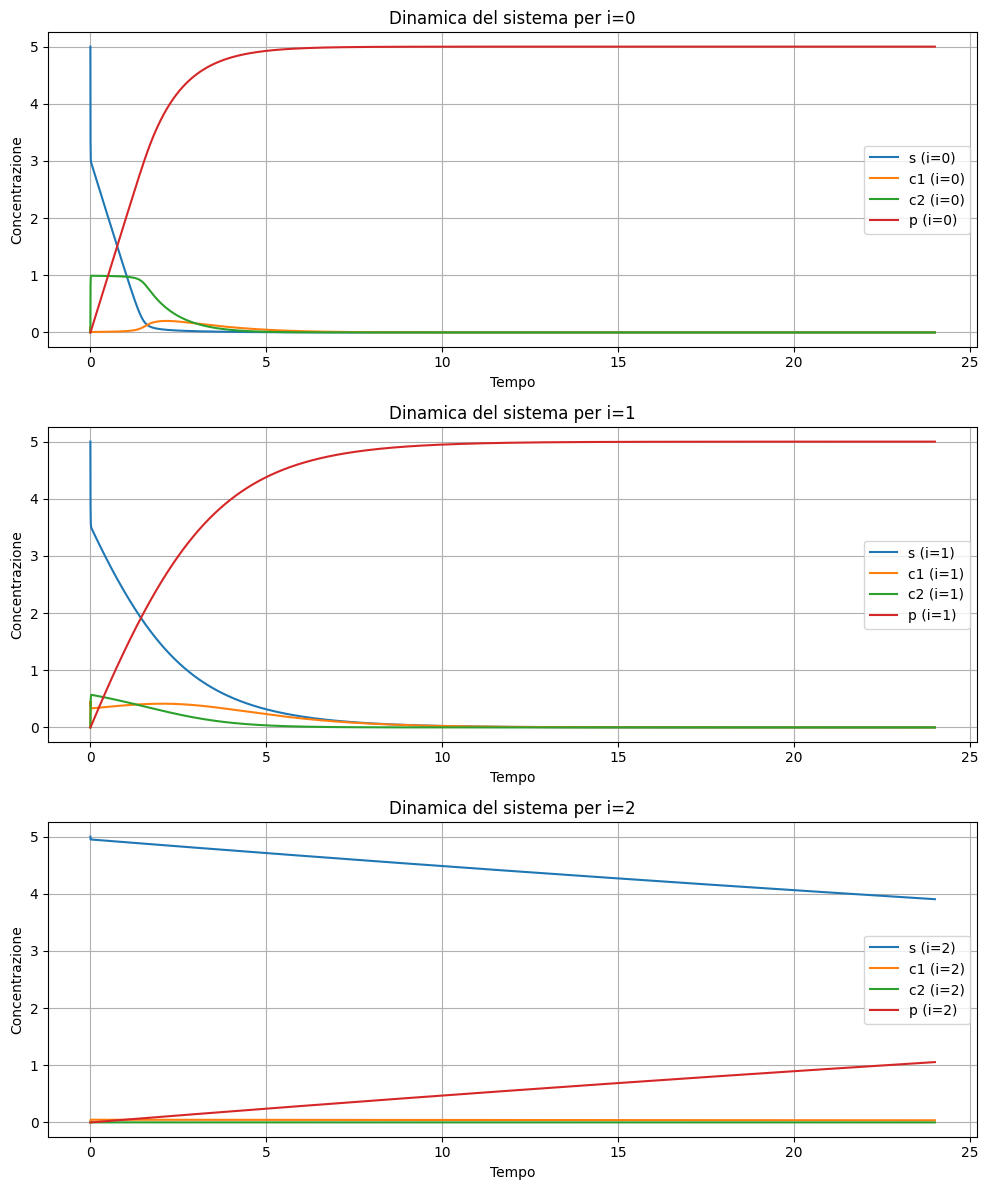

In [36]:
#System 

k_1 = [10, 100, 1000]
k1= [100, 100, 10]
k_3=[10, 100, 1000]
k3= [500, 50, 5]
k4= 2
k2= 1
s0= 5 
e0= 1


def cooperativity(y, t, k1, k_1, k3, k_3):
    s, c1, c2, p = y
    dsdt = -k1 * s * e0 + k1 *s * (c1 + c2) + k_1 * c1 - k3 * s * c1 + k_3 * c2
    dc1dt = k1 * s * e0 - (k_1 + k2) * c1 - k3 * s * c1 + (k4 + k_3) * c2 - k1 *s * (c1 + c2)
    dc2dt = k3 * s * c1 - (k4 + k_3) * c2
    dpdt = k2 * c1 + k4 * c2
    return [dsdt, dc1dt, dc2dt, dpdt]

y0 = [s0, 0, 0, 0]
t = np.linspace(0, 24, 10000)

fig, axes = plt.subplots(3, 1, figsize=(10, 12))  # 3 rows, 1 column

for i in range(3):
    solution = odeint(cooperativity, y0, t, args=(k1[i], k_1[i], k3[i], k_3[i]))
    s = solution[:, 0]
    c1 = solution[:, 1]
    c2 = solution[:, 2]
    p = solution[:, 3]
    

    axes[i].plot(t, s, label=f"s (i={i})")
    axes[i].plot(t, c1, label=f"c1 (i={i})")
    axes[i].plot(t, c2, label=f"c2 (i={i})")
    axes[i].plot(t, p, label=f"p (i={i})")
    axes[i].set_xlabel("Tempo")
    axes[i].set_ylabel("Concentrazione")
    axes[i].set_title(f"Dinamica del sistema per i={i}")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout() 
plt.show()
#LEGEND i= 0 (+ coop); i= 1 (indipendent); i=2 (- coop)

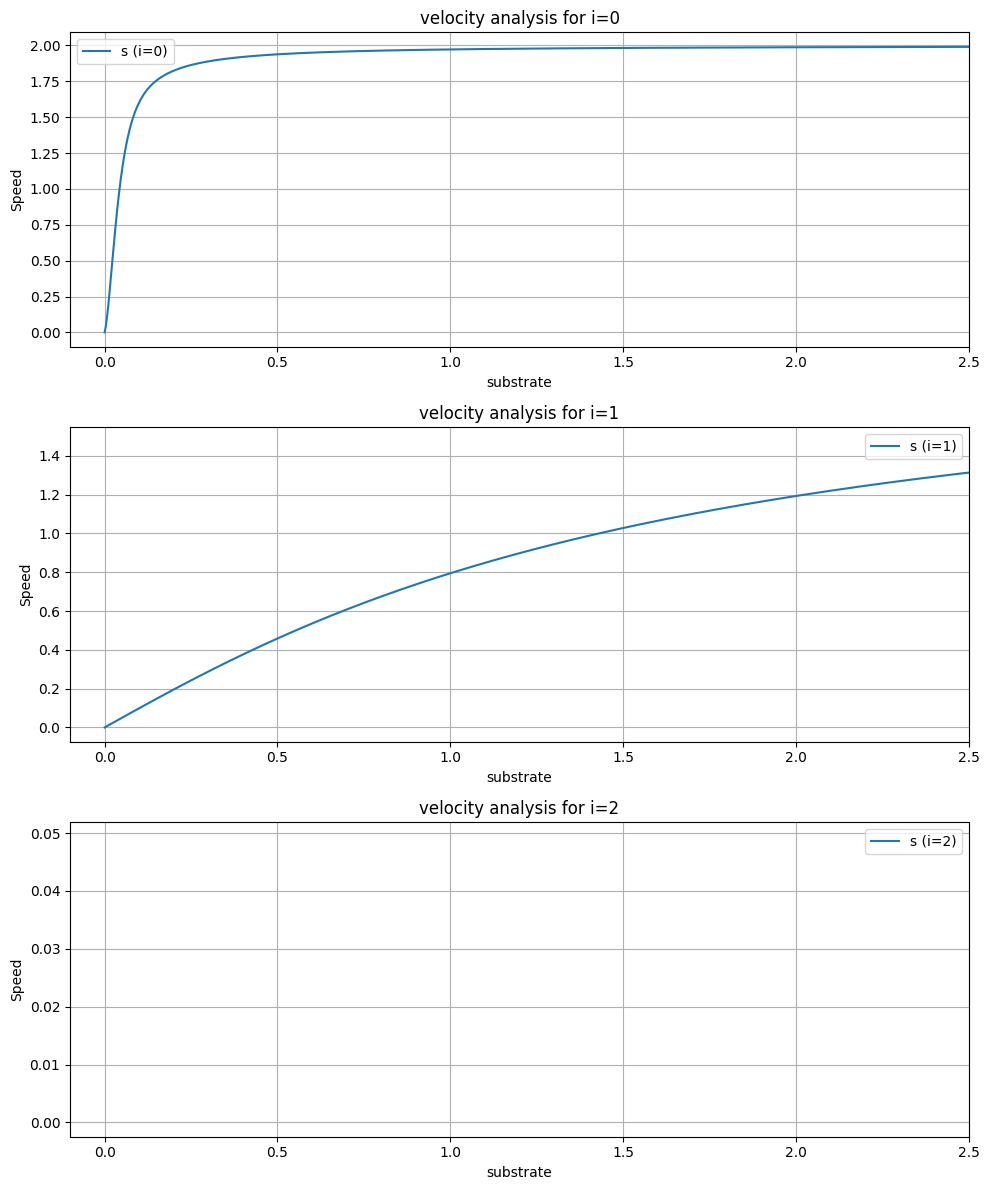

In [43]:
#graphic analysis of Velocity

fig, axes = plt.subplots(3, 1, figsize=(10, 12))  # 3 rows, 1 column

for i in range(3):
    solution = odeint(cooperativity, y0, t, args=(k1[i], k_1[i], k3[i], k_3[i]))
    s = solution[:, 0]
    c1 = solution[:, 1]
    c2 = solution[:, 2]
    v= k2*c1 + k4*c2


    axes[i].plot(s, v, label=f"s (i={i})")
    axes[i].set_xlabel("substrate")
    axes[i].set_ylabel("Speed")
    axes[i].set_title(f"velocity analysis for i={i}")
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(-0.1,2.5)

plt.tight_layout() 
plt.show()
  
# k1 << k3  (+) cooperativity 
# k1 = k3   no coop
# k1 >> k3  (-) cooperativity 



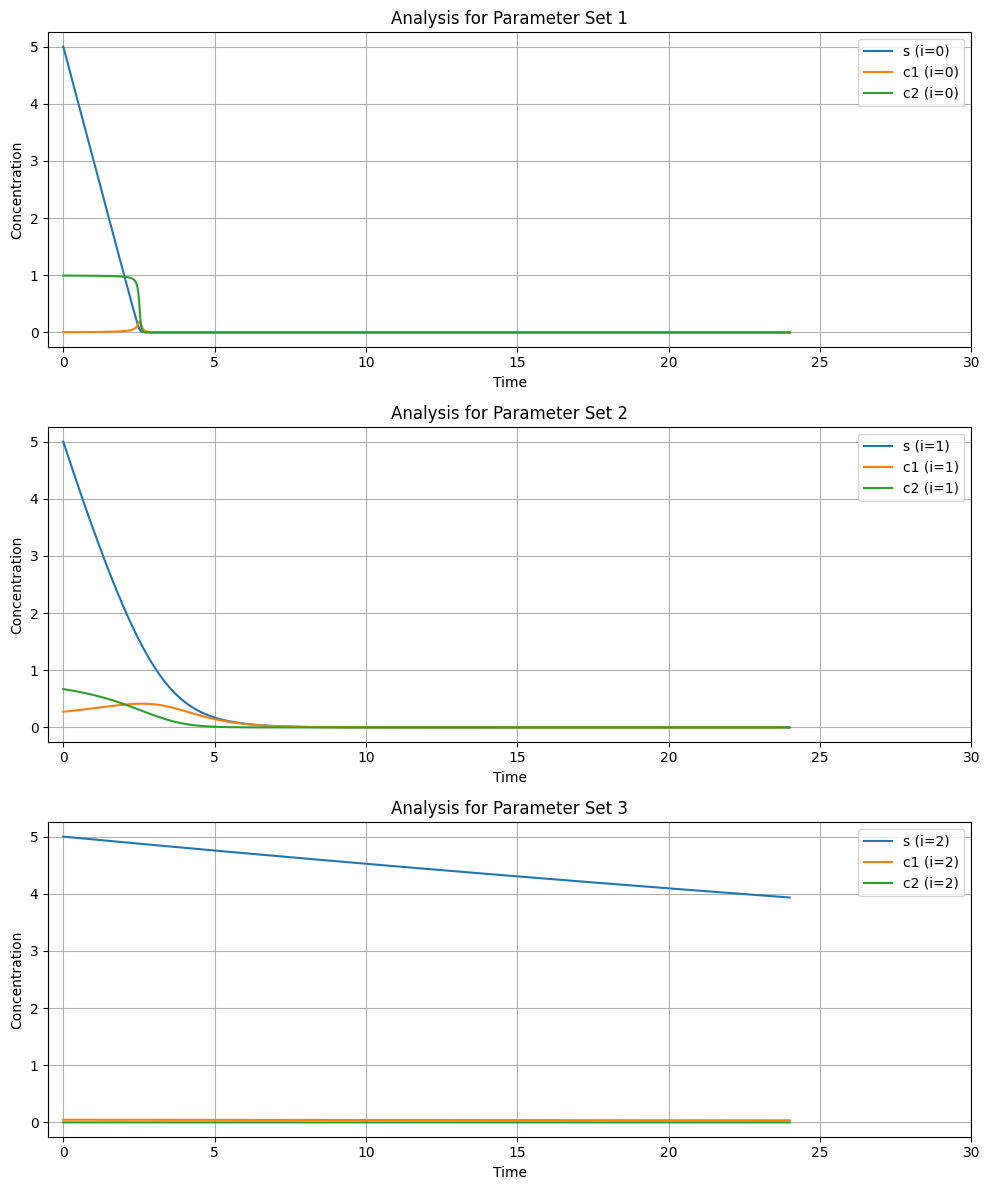

In [45]:
## Quasi-steady-state approximation

k_1_list = [10, 100, 1000]
k1_list = [100, 100, 10]
k_3_list =[10, 100, 1000]
k3_list = [500, 50, 5]
k2 = 1
k4 = 2
e0 = 1
s_app0 = [5]  # Initial condition should be a list for odeint to interpret properly


def coop_qs_approximation(s_app, t):
    s_app = s_app[0]  # Extract scalar from array
    km = (k_1 + k2) / k1
    kc = (k_3 + k4) / k3
   
    c1_app = (kc * e0 * s_app) / (kc * s_app + s_app**2 + km * kc)
    c2_app = (e0 * s_app**2) / (kc * s_app + s_app**2 + km * kc)
    dsdt_app = -k1 * s_app * e0 + k_1 * c1_app - k3 * s_app * c1_app + k_3 * c2_app + k1 * s_app* (c1_app + c2_app)

    return [dsdt_app] 



fig, axes = plt.subplots(3, 1, figsize=(10, 12)) 
for i in range(len(k1_list)):
    k1 = k1_list[i]
    k_1 = k_1_list[i]
    k3 = k3_list[i]
    k_3 = k_3_list[i]

    # Solve the ODE
    s_app = odeint(coop_qs_approximation, s0, t).flatten()

    # Calculate c1 and c2 based on s_app
    km = (k_1 + k2) / k1
    kc = (k_3 + k4) / k3
    c1_app = (kc * e0 * s_app) / (kc * s_app + s_app**2 + km * kc)
    c2_app = (e0 * s_app**2) / (kc * s_app + s_app**2 + km * kc)

    # Plot the results for the current parameter set
    axes[i].plot(t, s_app, label=f"s (i={i})")
    axes[i].plot(t, c1_app, label=f"c1 (i={i})")
    axes[i].plot(t, c2_app, label=f"c2 (i={i})")

    axes[i].set_ylabel("Concentration")
    axes[i].set_xlabel("Time")
    axes[i].set_title(f"Analysis for Parameter Set {i+1}")
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(-0.5,30)
    #axes[i].set_ylim(-0.5,2)



plt.tight_layout()
plt.show()



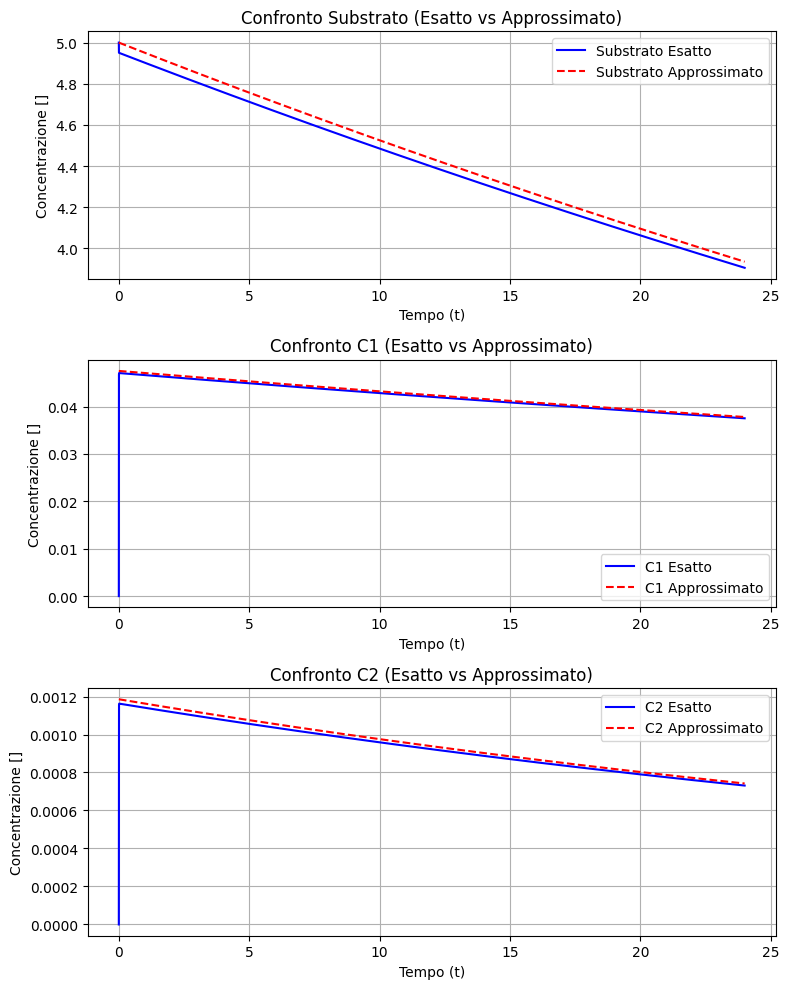

In [46]:
#Graphical analysis 
fig, axs = plt.subplots(3, 1, figsize=(8, 10))

# Subgraph 1: Confronto del Substrato (esatto vs approssimato)
axs[0].plot(t, s, label='Substrato Esatto', color='b')
axs[0].plot(t, s_app, label='Substrato Approssimato', color='r', linestyle='--')

axs[0].set_xlabel("Tempo (t)")
axs[0].set_ylabel('Concentrazione []')
axs[0].set_title('Confronto Substrato (Esatto vs Approssimato)')
axs[0].legend()
axs[0].grid(True)


# Sottografico 2: Confronto di C1 (esatto vs approssimato)
axs[1].plot(t, c1, label="C1 Esatto", color='b')
axs[1].plot(t, c1_app, label="C1 Approssimato", color='r', linestyle='--')

axs[1].set_xlabel("Tempo (t)")
axs[1].set_ylabel('Concentrazione []')
axs[1].set_title('Confronto C1 (Esatto vs Approssimato)')
axs[1].legend()
axs[1].grid(True)

# Sottografico 3: Confronto di C2 (esatto vs approssimato)
axs[2].plot(t, c2, label="C2 Esatto", color='b')
axs[2].plot(t, c2_app, label="C2 Approssimato", color='r', linestyle='--')

axs[2].set_xlabel("Tempo (t)")
axs[2].set_ylabel('Concentrazione []')
axs[2].set_title('Confronto C2 (Esatto vs Approssimato)')
axs[2].legend()
axs[2].grid(True)


# Migliora il layout per evitare sovrapposizioni
plt.tight_layout()

# Mostra tutti i sottografici
plt.show()

In [47]:
#Relative Error Analysis 
import random 
err_S = np.mean(np.abs(s - s_app) / s) 
err_C1 = np.mean(np.abs(c1[1:] - c1_app[1:]) / c1[1:]) 
err_C2 = np.mean(np.abs(c2[1:] - c2_app[1:]) / c2[1:])   ## COME FIXO?

print ("Relative error of Substrate:", err_S)
print ("Relative error of Compound 1:", err_C1)
print ("Relative error of Compound 2:", err_C2)


Relative error of Substrate: 0.008778516954633112
Relative error of Compound 1: 0.008388558849877267
Relative error of Compound 2: 0.01726059920160842
